# Task 1: Data Preprocessing

**Student Dropout and Academic Success Dataset**

This notebook covers:
1. Loading and inspecting the dataset
2. Handling missing values
3. Encoding categorical features
4. Standardizing numerical features
5. Summary of observed patterns and insights

In [1]:
import sys
import os

# Add project root to path so src can be imported
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import preprocessing utilities
from src.preprocessing import (
    load_data,
    get_feature_types,
    handle_missing_values,
    encode_features,
    standardize_features,
    preprocess_pipeline,
)

# Import data fetcher — auto-downloads dataset if not present
from src.fetch_data import download_dataset

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

## 1. Load and Inspect Data

In [2]:
# Download raw data (skipped if already present)
data_dir = os.path.join(project_root, "data")
download_dataset(data_dir=data_dir)

# Load raw data
X, y = load_data(data_dir=data_dir)

Data files already exist, skipping download.
Loaded 4424 samples, 36 features
Target classes: {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794


In [3]:
print("\n=== Feature Data Types ===")
print(X.dtypes.value_counts())
print(f"\nTotal features: {X.shape[1]}")
print(f"Total samples: {X.shape[0]}")


=== Feature Data Types ===
int64      29
float64     7
Name: count, dtype: int64

Total features: 36
Total samples: 4424


In [4]:
print("\n=== Basic Statistics (first 10 features) ===")
X.iloc[:, :10].describe().T


=== Basic Statistics (first 10 features) ===


,count,mean,std,min,25%,50%,75%,max
Marital Status,4424.0,1.178571,0.605747,1.0,1.0,1.0,1.0,6.0
Application mode,4424.0,18.669078,17.484682,1.0,1.0,17.0,39.0,57.0
Application order,4424.0,1.727848,1.313793,0.0,1.0,1.0,2.0,9.0
Course,4424.0,8856.642631,2063.566416,33.0,9085.0,9238.0,9556.0,9991.0
Daytime/evening attendance,4424.0,0.890823,0.311897,0.0,1.0,1.0,1.0,1.0
Previous qualification,4424.0,4.577758,10.216592,1.0,1.0,1.0,1.0,43.0
Previous qualification (grade),4424.0,132.613314,13.188332,95.0,125.0,133.1,140.0,190.0
Nacionality,4424.0,1.873192,6.914514,1.0,1.0,1.0,1.0,109.0
Mother's qualification,4424.0,19.561935,15.603186,1.0,2.0,19.0,37.0,44.0
Father's qualification,4424.0,22.275316,15.343108,1.0,3.0,19.0,37.0,44.0


In [5]:
print("\n=== Basic Statistics (remaining features) ===")
X.iloc[:, 10:].describe().T


=== Basic Statistics (remaining features) ===


,count,mean,std,min,25%,50%,75%,max
Mother's occupation,4424.0,10.960895,26.418253,0.00,4.00,5.000000,9.000000,194.000000
Father's occupation,4424.0,11.032324,25.263040,0.00,4.00,7.000000,9.000000,195.000000
Admission grade,4424.0,126.978119,14.482001,95.00,117.90,126.100000,134.800000,190.000000
Displaced,4424.0,0.548373,0.497711,0.00,0.00,1.000000,1.000000,1.000000
Educational special needs,4424.0,0.011528,0.106760,0.00,0.00,0.000000,0.000000,1.000000
Debtor,4424.0,0.113698,0.317480,0.00,0.00,0.000000,0.000000,1.000000
Tuition fees up to date,4424.0,0.880651,0.324235,0.00,1.00,1.000000,1.000000,1.000000
Gender,4424.0,0.351718,0.477560,0.00,0.00,0.000000,1.000000,1.000000
Scholarship holder,4424.0,0.248418,0.432144,0.00,0.00,0.000000,0.000000,1.000000
Age at enrollment,4424.0,23.265145,7.587816,17.00,19.00,20.000000,25.000000,70.000000


## 2. Feature Type Classification

Features are classified into four groups based on their semantics:

- **Nominal**: Unordered categories (e.g., marital status, course)
- **Binary**: 0/1 indicator variables (e.g., gender, scholarship)
- **Count**: Integer counts (e.g., enrolled credits, approved credits)
- **Continuous**: Floating-point values (e.g., admission grade, GDP)

In [6]:
# Get feature type classification
feature_types = get_feature_types(X)

print(f"Nominal features ({len(feature_types['nominal'])}):")
for f in feature_types["nominal"]:
    print(f"  - {f} (unique: {X[f].nunique()})")

print(f"\nBinary features ({len(feature_types['binary'])}):")
for f in feature_types["binary"]:
    print(f"  - {f}")

print(f"\nCount features ({len(feature_types['count'])}):")
for f in feature_types["count"]:
    print(f"  - {f}")

print(f"\nContinuous features ({len(feature_types['continuous'])}):")
for f in feature_types["continuous"]:
    print(f"  - {f}")

Nominal features (8):
  - Marital Status (unique: 6)
  - Application mode (unique: 18)
  - Course (unique: 17)
  - Nacionality (unique: 21)
  - Mother's qualification (unique: 29)
  - Father's qualification (unique: 34)
  - Mother's occupation (unique: 32)
  - Father's occupation (unique: 46)

Binary features (8):
  - Daytime/evening attendance
  - Displaced
  - Educational special needs
  - Debtor
  - Tuition fees up to date
  - Gender
  - Scholarship holder
  - International

Count features (13):
  - Age at enrollment
  - Application order
  - Curricular units 1st sem (approved)
  - Curricular units 1st sem (credited)
  - Curricular units 1st sem (enrolled)
  - Curricular units 1st sem (evaluations)
  - Curricular units 1st sem (without evaluations)
  - Curricular units 2nd sem (approved)
  - Curricular units 2nd sem (credited)
  - Curricular units 2nd sem (enrolled)
  - Curricular units 2nd sem (evaluations)
  - Curricular units 2nd sem (without evaluations)
  - Previous qualificati

## 3. Target Distribution

The dataset contains three classes: **Graduate** (majority class), **Dropout**, and **Enrolled**.

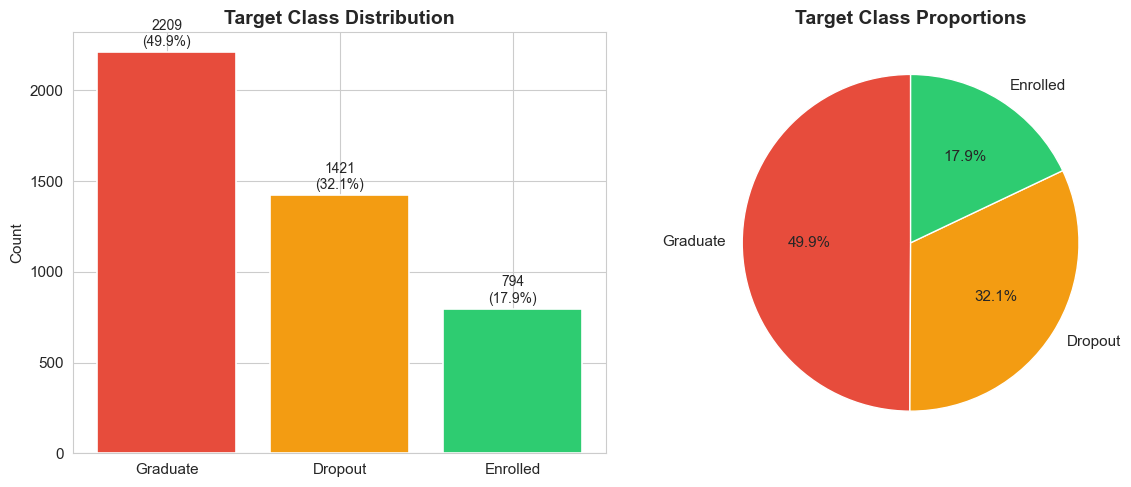

In [7]:
# Map numeric labels to class names
target_names = {0: "Dropout", 1: "Enrolled", 2: "Graduate"}
y_named = y.map(target_names)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
counts = y_named.value_counts()
colors = ["#e74c3c", "#f39c12", "#2ecc71"]
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=1.2)
axes[0].set_title("Target Class Distribution", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Count")
# Annotate count and percentage on top of bars
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 f"{val}\n({val/len(y)*100:.1f}%)", ha="center", va="bottom", fontsize=10)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=colors, autopct="%1.1f%%",
            startangle=90, textprops={"fontsize": 11})
axes[1].set_title("Target Class Proportions", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

**Observation**: The dataset exhibits **class imbalance** — Graduate (49.9%) dominates, Enrolled (18.0%) is the smallest. This may affect model training and evaluation.

## 4. Missing Value Analysis

In [8]:
X_clean, missing_info = handle_missing_values(X, strategy="median")
print(f"\nMissing info: {missing_info}")

No missing values found.

Missing info: {'total_missing': 0, 'missing_per_column': {}, 'strategy': 'median'}


**Result**: No missing values were detected in the dataset. This is a complete dataset.

## 5. Feature Encoding

Nominal categorical features are one-hot encoded to avoid introducing artificial ordinal relationships.

In [9]:
X_encoded = encode_features(X_clean, feature_types, method="onehot")
print(f"Shape before encoding: {X_clean.shape}")
print(f"Shape after encoding:  {X_encoded.shape}")
print(f"New features added: {X_encoded.shape[1] - X_clean.shape[1]}")

One-hot encoded 8 nominal features. New shape: (4424, 231)
Shape before encoding: (4424, 36)
Shape after encoding:  (4424, 231)
New features added: 195


## 6. Feature Standardization

Continuous and count features are standardized to zero mean and unit variance. Binary features are kept as-is.

In [10]:
X_scaled, scaler = standardize_features(X_encoded, feature_types, fit=True)
print(f"Final shape: {X_scaled.shape}")

Standardized 20 numerical features (fit).
Final shape: (4424, 231)


In [11]:
print("\n=== Standardized Features (sample) ===")
scale_cols = feature_types["continuous"] + feature_types["count"]
scale_cols = [c for c in scale_cols if c in X_scaled.columns]
X_scaled[scale_cols].describe().T


=== Standardized Features (sample) ===


,count,mean,std,min,25%,50%,75%,max
Previous qualification (grade),4424.0,-3.589654e-16,1.000113,-2.852337,-0.577342,0.036907,0.560156,4.351815
Admission grade,4424.0,-9.708930e-16,1.000113,-2.208378,-0.626926,-0.060642,0.540172,4.352230
Curricular units 1st sem (grade),4424.0,-1.702476e-16,1.000113,-2.197102,0.074163,0.339635,0.569711,1.700182
Curricular units 2nd sem (grade),4424.0,3.212219e-17,1.000113,-1.963489,0.099764,0.378064,0.595585,1.600935
Unemployment rate,4424.0,-5.460771e-17,1.000113,-1.489043,-0.813253,-0.175007,0.876222,1.739731
Inflation rate,4424.0,1.445498e-16,1.000113,-1.466871,-0.671242,0.124386,0.992345,1.787974
GDP,4424.0,2.569775e-17,1.000113,-1.789667,-0.749872,0.140122,0.787790,1.545607
Age at enrollment,4424.0,-1.027910e-16,1.000113,-0.825778,-0.562168,-0.430363,0.228663,6.159894
Application order,4424.0,-1.043971e-16,1.000113,-1.315309,-0.554068,-0.554068,0.207173,5.535860
Curricular units 1st sem (approved),4424.0,3.051608e-17,1.000113,-1.521257,-0.551604,0.094832,0.418050,6.882407


## 7. Feature Correlation with Target

/var/folders/kq/6zxlnzb91cg7xmnr5cqn5tjw0000gn/T/ipykernel_47402/3636447588.py:14: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kq/6zxlnzb91cg7xmnr5cqn5tjw0000gn/T/ipykernel_47402/3636447588.py:14: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kq/6zxlnzb91cg7xmnr5cqn5tjw0000gn/T/ipykernel_47402/3636447588.py:14: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kq/6zxlnzb91cg7xmnr5cqn5tjw0000gn/T/ipykernel_47402/3636447588.py:14: UserWarning: Glyph 30446 (\N{CJK UNIFIED IDEOGRAPH-76EE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kq/6zxlnzb91cg7xmnr5cqn5tjw0000gn/T/ipykernel_47402/3636447588.py:14: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kq/6zxlnzb91cg7xmnr5cqn5tjw0000gn/T/i

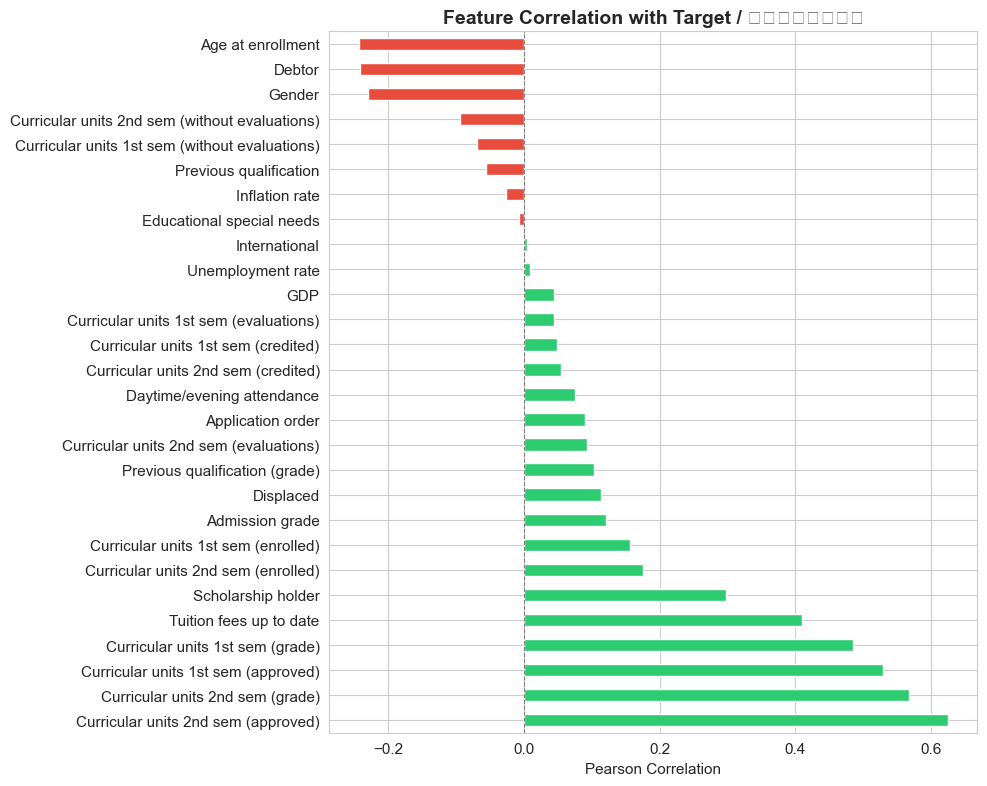

In [12]:
# Compute Pearson correlation of each feature with the target
numeric_cols = feature_types["continuous"] + feature_types["count"] + feature_types["binary"]
full_corr = X[numeric_cols].copy()
full_corr["Target"] = y
target_corr = full_corr.corr()["Target"].drop("Target").sort_values(ascending=False)

# Plot horizontal bar chart of correlations
fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = ["#e74c3c" if v < 0 else "#2ecc71" for v in target_corr.values]
target_corr.plot(kind="barh", ax=ax, color=colors_bar, edgecolor="white")
ax.set_title("Feature Correlation with Target / 特征与目标相关性", fontsize=14, fontweight="bold")
ax.set_xlabel("Pearson Correlation")
ax.axvline(x=0, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.savefig(os.path.join(project_root, "data", "plots", "02_feature_target_correlation.png"), dpi=150, bbox_inches="tight")
plt.show()

## 8. Summary & Insights

### Preprocessing Steps Applied
1. **Missing values**: No missing values found; dataset is complete
2. **Feature encoding**: 8 nominal features one-hot encoded (e.g., marital status, course, application mode), dimensions expanded from 36 to ~220
3. **Standardization**: Continuous and count features standardized (zero mean, unit variance); binary features kept as-is

### Key Observations
- Dataset has **4,424 samples** and **36 original features**
- **Class imbalance**: Graduate (49.9%) > Dropout (32.1%) > Enrolled (18.0%); models may need class weights or SMOTE
- **Course performance indicators** (approved credits, grades) are strongly correlated with the target, the most predictive features
- **Tuition fee status** is also an important predictor — students with outstanding tuition are more likely to drop out
- **Macroeconomic features** (GDP, inflation rate, unemployment rate) have weak correlation, limited contribution to prediction
- **Scholarship holders** tend to graduate; **debtor students** tend to drop out

In [13]:
X_scaled.to_csv(os.path.join(project_root, "data", "features_processed.csv"), index=False)
y.to_frame().to_csv(os.path.join(project_root, "data", "targets_processed.csv"), index=False)
print("Processed data saved to data/features_processed.csv")

Processed data saved to data/features_processed.csv
